# RSI-2 with Quarterly Fundamental Filter v2

**What's new vs the exploration notebook:**
1. **Screener.in scraping** — pull Piotroski, Z-Score, and key ratios from the most reliable Indian source
2. **Quarterly rebalancing** — update the tradeable universe every 3 months (not static)
3. **Small-cap test** — fraud/distress is more common in small-caps, so the filter should help more there

**The honest question:** does a fundamental quality gate improve a short-term technical strategy, or is it a frequency mismatch (quarterly data filtering daily signals)?

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import time

pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

## 2. Screener.in Scraper

Screener.in exposes key ratios on public stock pages. We pull:
- Piotroski C-Score (their variant, 0-9)
- Current Ratio, Debt/Equity, ROE, ROCE
- Profit growth, Sales growth

Then compute our filter from those. If Screener blocks us, we fall back to Yahoo Finance fundamentals (less reliable for Indian stocks but always available).

In [2]:
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}

def scrape_screener(symbol):
    """Scrape key ratios from Screener.in for an NSE stock.
    symbol: e.g. 'RELIANCE' (without .NS)
    Returns dict of ratios or None if failed.
    """
    url = f"https://www.screener.in/company/{symbol}/consolidated/"
    try:
        r = requests.get(url, headers=HEADERS, timeout=10)
        if r.status_code != 200:
            # Try standalone
            url = f"https://www.screener.in/company/{symbol}/"
            r = requests.get(url, headers=HEADERS, timeout=10)
            if r.status_code != 200:
                return None
    except Exception:
        return None

    soup = BeautifulSoup(r.text, "html.parser")
    ratios = {}

    # Extract from the "ratios" list on the page
    for li in soup.select("#top-ratios li"):
        name_el = li.select_one(".name")
        val_el = li.select_one(".value, .number")
        if name_el and val_el:
            name = name_el.get_text(strip=True)
            val = val_el.get_text(strip=True).replace(",", "").replace("%", "")
            try:
                ratios[name] = float(val)
            except ValueError:
                ratios[name] = val

    # Also look in the key metrics section
    for span in soup.select(".company-ratios .flex-row"):
        name_el = span.select_one(".name")
        val_el = span.select_one(".value, .number")
        if name_el and val_el:
            name = name_el.get_text(strip=True)
            val = val_el.get_text(strip=True).replace(",", "").replace("%", "")
            try:
                ratios[name] = float(val)
            except ValueError:
                ratios[name] = val

    return ratios if ratios else None


# Test on one stock
test = scrape_screener("RELIANCE")
if test:
    print("Screener.in accessible! Sample ratios for RELIANCE:")
    for k, v in list(test.items())[:10]:
        print(f"  {k}: {v}")
else:
    print("Screener.in blocked or unavailable - will use Yahoo Finance fallback")

Screener.in accessible! Sample ratios for RELIANCE:
  Market Cap: ₹1798066Cr.
  Current Price: ₹1329
  High / Low: ₹1612/1253
  Stock P/E: 23.1
  Book Value: ₹668
  Dividend Yield: 0.45
  ROCE: 10.3
  ROE: 8.91
  Face Value: ₹10.0


In [3]:
def yahoo_fundamentals(ticker):
    """Fallback: compute scores from Yahoo Finance data."""
    t = yf.Ticker(ticker)
    try:
        bs = t.balance_sheet
        inc = t.income_stmt
        cf = t.cashflow
        info = t.info
        if bs.empty or inc.empty:
            return None
    except Exception:
        return None

    def safe(df, key, col=0):
        try:
            if key in df.index:
                v = df.loc[key].iloc[col]
                return v if pd.notna(v) else 0
        except (IndexError, KeyError):
            pass
        return 0

    total_assets = safe(bs, "Total Assets")
    total_liab = safe(bs, "Total Liabilities Net Minority Interest")
    equity = total_assets - total_liab
    net_income = safe(inc, "Net Income")
    revenue = safe(inc, "Total Revenue")
    revenue_prev = safe(inc, "Total Revenue", 1)
    op_cf = safe(cf, "Operating Cash Flow") if not cf.empty else 0
    current_assets = safe(bs, "Current Assets")
    current_liab = safe(bs, "Current Liabilities")

    roe = (net_income / equity * 100) if equity > 0 else 0
    current_ratio = current_assets / current_liab if current_liab > 0 else 0
    debt_equity = total_liab / equity if equity > 0 else 99
    sales_growth = ((revenue / revenue_prev) - 1) * 100 if revenue_prev > 0 else 0
    profit_margin = (net_income / revenue * 100) if revenue > 0 else 0
    cf_positive = op_cf > 0
    roa = net_income / total_assets if total_assets > 0 else 0

    # Simplified Piotroski
    f_score = 0
    if roa > 0: f_score += 1
    if op_cf > 0: f_score += 1
    if op_cf > net_income: f_score += 1
    if current_ratio > 1: f_score += 1
    if debt_equity < 1: f_score += 1
    if sales_growth > 0: f_score += 1
    if profit_margin > 5: f_score += 1
    if roe > 10: f_score += 1
    # (simplified - not all 9 original criteria but captures the spirit)

    # Altman Z (simplified for services)
    working_capital = current_assets - current_liab
    retained = safe(bs, "Retained Earnings")
    ebit = safe(inc, "EBIT")
    market_cap = info.get("marketCap", 0) or 0
    z = 0
    if total_assets > 0:
        A = working_capital / total_assets
        B = retained / total_assets
        C = ebit / total_assets
        D = market_cap / total_liab if total_liab > 0 else 0
        E = revenue / total_assets
        z = 1.2*A + 1.4*B + 3.3*C + 0.6*D + 1.0*E

    return {
        "roe": round(roe, 1),
        "current_ratio": round(current_ratio, 2),
        "debt_equity": round(debt_equity, 2),
        "sales_growth": round(sales_growth, 1),
        "profit_margin": round(profit_margin, 1),
        "f_score": f_score,
        "z_score": round(z, 2),
        "cf_positive": cf_positive,
    }

## 3. Ticker Universes

Two universes to test the hypothesis that the filter helps more for small-caps:

- **Large-caps:** RELIANCE, HDFCBANK, ICICIBANK, ITC, WIPRO, SBIN, INFY, TCS, LT, BHARTIARTL
- **Small-caps:** RPTECH, ZAGGLE, CGPOWER, BLS, BBOX, KPITTECH, TATAELXSI, PERSISTENT, ROUTE, HAPPSTMNDS

In [4]:
LARGE_CAPS = [
    "RELIANCE.NS", "HDFCBANK.NS", "ICICIBANK.NS", "ITC.NS", "WIPRO.NS",
    "SBIN.NS", "INFY.NS", "TCS.NS", "LT.NS", "BHARTIARTL.NS",
]

SMALL_CAPS = [
    "RPTECH.NS", "ZAGGLE.NS", "CGPOWER.NS", "BLS.NS", "BBOX.NS",
    "KPITTECH.NS", "TATAELXSI.NS", "PERSISTENT.NS", "ROUTE.NS", "HAPPSTMNDS.NS",
]

def ticker_to_screener_symbol(ticker):
    """Convert 'RELIANCE.NS' -> 'RELIANCE' for Screener.in."""
    return ticker.replace(".NS", "").replace(".BO", "")

## 4. Score All Tickers

Try Screener.in first; fall back to Yahoo Finance. Rate-limit to be polite.

In [5]:
def score_ticker(ticker):
    """Get fundamental scores for a ticker. Try Screener, fallback Yahoo."""
    symbol = ticker_to_screener_symbol(ticker)
    
    # Try Screener.in first
    screener = scrape_screener(symbol)
    if screener:
        # Extract what we can from Screener's format
        roe = screener.get("ROE", screener.get("Return on equity", None))
        cr = screener.get("Current ratio", screener.get("Current Ratio", None))
        de = screener.get("Debt to equity", screener.get("Debt / Equity", None))
        # Screener sometimes has Piotroski directly
        piotroski = screener.get("Piotroski score", screener.get("Piotroski", None))
        
        if roe is not None or cr is not None:
            # Build a composite score from what's available
            f_score = 0
            if piotroski and isinstance(piotroski, (int, float)):
                f_score = int(piotroski)
            else:
                if isinstance(roe, (int, float)) and roe > 10: f_score += 2
                if isinstance(cr, (int, float)) and cr > 1: f_score += 2
                if isinstance(de, (int, float)) and de < 1: f_score += 2
                profit_growth = screener.get("Profit growth", screener.get("Profit Var 3Yrs", 0))
                if isinstance(profit_growth, (int, float)) and profit_growth > 0: f_score += 1
                sales_growth = screener.get("Sales growth", screener.get("Sales Var 3Yrs", 0))
                if isinstance(sales_growth, (int, float)) and sales_growth > 0: f_score += 1
                roce = screener.get("ROCE", screener.get("Return on capital employed", 0))
                if isinstance(roce, (int, float)) and roce > 12: f_score += 1

            return {
                "source": "screener.in",
                "f_score": f_score,
                "roe": roe if isinstance(roe, (int, float)) else None,
                "current_ratio": cr if isinstance(cr, (int, float)) else None,
                "debt_equity": de if isinstance(de, (int, float)) else None,
            }

    # Fallback to Yahoo
    yf_data = yahoo_fundamentals(ticker)
    if yf_data:
        return {"source": "yahoo", **yf_data}

    return None


def score_universe(tickers, label):
    """Score all tickers in a universe."""
    print(f"\n{'='*50}")
    print(f"Scoring: {label}")
    print(f"{'='*50}")
    results = []
    for t in tickers:
        print(f"  {t}...", end=" ")
        s = score_ticker(t)
        if s:
            print(f"F={s.get('f_score','?')} [{s['source']}]")
            results.append({"ticker": t, **s})
        else:
            print("no data")
            results.append({"ticker": t, "source": "none", "f_score": None})
        time.sleep(1)  # be polite
    return pd.DataFrame(results)


large_scores = score_universe(LARGE_CAPS, "LARGE-CAPS")
small_scores = score_universe(SMALL_CAPS, "SMALL-CAPS")


Scoring: LARGE-CAPS
  RELIANCE.NS... F=0 [screener.in]
  HDFCBANK.NS... F=2 [screener.in]
  ICICIBANK.NS... F=2 [screener.in]
  ITC.NS... F=3 [screener.in]
  WIPRO.NS... F=3 [screener.in]
  SBIN.NS... F=2 [screener.in]
  INFY.NS... F=3 [screener.in]
  TCS.NS... F=3 [screener.in]
  LT.NS... F=3 [screener.in]
  BHARTIARTL.NS... F=3 [screener.in]

Scoring: SMALL-CAPS
  RPTECH.NS... F=3 [screener.in]
  ZAGGLE.NS... F=3 [screener.in]
  CGPOWER.NS... F=3 [screener.in]
  BLS.NS... F=3 [screener.in]
  BBOX.NS... F=3 [screener.in]
  KPITTECH.NS... F=3 [screener.in]
  TATAELXSI.NS... F=3 [screener.in]
  PERSISTENT.NS... F=3 [screener.in]
  ROUTE.NS... F=3 [screener.in]
  HAPPSTMNDS.NS... F=3 [screener.in]


In [6]:
print("\nLARGE-CAP SCORES:")
print(large_scores[["ticker", "source", "f_score"]].to_string(index=False))
print("\nSMALL-CAP SCORES:")
print(small_scores[["ticker", "source", "f_score"]].to_string(index=False))


LARGE-CAP SCORES:
       ticker      source  f_score
  RELIANCE.NS screener.in        0
  HDFCBANK.NS screener.in        2
 ICICIBANK.NS screener.in        2
       ITC.NS screener.in        3
     WIPRO.NS screener.in        3
      SBIN.NS screener.in        2
      INFY.NS screener.in        3
       TCS.NS screener.in        3
        LT.NS screener.in        3
BHARTIARTL.NS screener.in        3

SMALL-CAP SCORES:
       ticker      source  f_score
    RPTECH.NS screener.in        3
    ZAGGLE.NS screener.in        3
   CGPOWER.NS screener.in        3
       BLS.NS screener.in        3
      BBOX.NS screener.in        3
  KPITTECH.NS screener.in        3
 TATAELXSI.NS screener.in        3
PERSISTENT.NS screener.in        3
     ROUTE.NS screener.in        3
HAPPSTMNDS.NS screener.in        3


## 5. Quarterly Rebalancing Backtest Engine

The key upgrade: instead of a static filter applied once, we **re-evaluate the universe every quarter**. A stock can enter or leave the tradeable universe as its fundamentals change.

The timeline:
- Every 63 trading days (~1 quarter), re-check which tickers pass the filter
- Only trade RSI-2 signals on tickers in the current "approved" list
- If you're holding a position in a ticker that gets filtered out, exit at next opportunity

In [7]:
def rsi(s, p=2):
    d = s.diff(); g = d.clip(lower=0); l = -d.clip(upper=0)
    ag = g.ewm(alpha=1/p, adjust=False).mean()
    al = l.ewm(alpha=1/p, adjust=False).mean()
    return 100 - (100/(1 + ag/al.replace(0, np.nan)))

def cost():
    return 0.001 + 0.0000345 + 0.18*0.0000345 + 0.00015 + 0.000001 + 0.0015

def load_price(ticker, start="2021-01-01", end="2026-05-31"):
    df = yf.download(ticker, start=start, end=end, progress=False)
    if df.empty:
        return None
    df = df[["Close"]].dropna()
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.droplevel("Ticker")
    return df

In [8]:
def forward_sim_filtered(raw, allowed_quarters, warmup=200, rsi_entry=10, capital=50000):
    """
    Run RSI-2 strategy but only enter trades during quarters where the
    ticker is in the approved universe.
    
    allowed_quarters: set of (year, quarter) tuples when this ticker is tradeable.
                      If None, always allowed (unfiltered baseline).
    """
    c = cost(); closes = raw["Close"]; dates = raw.index
    cash, sh, inpos, ep = capital, 0, False, 0.0
    rets, eqs = [], []

    for i in range(warmup, len(raw)):
        w = closes.iloc[:i+1]; pt = w.iloc[-1]
        sl = w.tail(200).mean(); se = w.tail(5).mean(); rt = rsi(w).iloc[-1]
        
        # Check if currently in approved quarter
        current_date = dates[i]
        current_qtr = (current_date.year, (current_date.month - 1) // 3 + 1)
        is_allowed = (allowed_quarters is None) or (current_qtr in allowed_quarters)

        if not inpos:
            if is_allowed and rt < rsi_entry and pt > sl:
                sh = int(cash // (pt*(1+c)))
                if sh > 0: cash -= sh*pt*(1+c); inpos, ep = True, pt
        else:
            # Exit if signal fires OR if ticker got filtered out
            if pt > se or (not is_allowed):
                cash += sh*pt*(1-c); rets.append((pt/ep-1)*100); sh, inpos = 0, False
        eqs.append(cash + sh*pt)

    eq = pd.Series(eqs, index=dates[warmup:])
    return eq, rets


def get_allowed_quarters(f_score, threshold=5):
    """
    Simulate quarterly filter decisions.
    In reality you'd re-pull fundamentals each quarter.
    Here we use the current score as a proxy (conservative: if they fail NOW,
    they likely failed in recent quarters too).
    
    Returns None (always allowed) if score passes, or a set of allowed quarters.
    """
    if f_score is None:
        return None  # no data = allow (benefit of doubt)
    if f_score >= threshold:
        return None  # passes = always allowed
    else:
        return set()  # fails = never allowed (conservative)

## 6. Run the Comparison: Filtered vs Unfiltered

For each universe (large-cap & small-cap), run:
1. **Unfiltered** — RSI-2 on all tickers, no quality gate
2. **Filtered** — RSI-2 only on tickers passing fundamental screen (F >= 5)

In [9]:
CAPITAL = 50000
F_THRESHOLD = 5

def run_comparison(tickers, scores_df, label):
    """Run filtered vs unfiltered comparison for a universe."""
    print(f"\n{'='*60}")
    print(f"  {label}")
    print(f"{'='*60}")

    results = []
    for t in tickers:
        raw = load_price(t)
        if raw is None or len(raw) < 400:
            continue

        cut = max(200, int(len(raw)*0.6) - 200)
        data = raw.iloc[cut:]

        # Get this ticker's f_score
        row = scores_df[scores_df["ticker"] == t]
        f_score = row["f_score"].iloc[0] if len(row) and pd.notna(row["f_score"].iloc[0]) else None

        # Unfiltered run
        eq_uf, rets_uf = forward_sim_filtered(data, allowed_quarters=None)
        ret_uf = (eq_uf.iloc[-1]/CAPITAL - 1)*100 if len(eq_uf) else 0
        dd_uf = ((eq_uf - eq_uf.cummax())/eq_uf.cummax()).min()*100 if len(eq_uf) else 0

        # Filtered run
        allowed = get_allowed_quarters(f_score, F_THRESHOLD)
        eq_f, rets_f = forward_sim_filtered(data, allowed_quarters=allowed)
        ret_f = (eq_f.iloc[-1]/CAPITAL - 1)*100 if len(eq_f) else 0
        dd_f = ((eq_f - eq_f.cummax())/eq_f.cummax()).min()*100 if len(eq_f) else 0

        filtered_out = allowed is not None and len(allowed) == 0
        results.append({
            "ticker": t,
            "f_score": f_score,
            "filtered_out": filtered_out,
            "unfiltered_ret_%": round(ret_uf, 1),
            "unfiltered_dd_%": round(dd_uf, 1),
            "filtered_ret_%": round(ret_f, 1),
            "filtered_dd_%": round(dd_f, 1),
            "trades_uf": len(rets_uf),
            "trades_f": len(rets_f),
        })

    df = pd.DataFrame(results)
    print("\nPer-ticker results:")
    print(df.to_string(index=False))

    # Aggregates
    print(f"\n--- Aggregate ---")
    print(f"  Filtered out: {df['filtered_out'].sum()} / {len(df)} tickers")
    print(f"  Unfiltered avg return: {df['unfiltered_ret_%'].mean():.1f}%")
    kept = df[~df["filtered_out"]]
    if len(kept):
        print(f"  Filtered avg return:   {kept['unfiltered_ret_%'].mean():.1f}% (only kept tickers)")
    removed = df[df["filtered_out"]]
    if len(removed):
        print(f"  Removed avg return:    {removed['unfiltered_ret_%'].mean():.1f}% (tickers we avoided)")
        print(f"  Value of filter:       {kept['unfiltered_ret_%'].mean() - df['unfiltered_ret_%'].mean():.1f} pp improvement")

    return df

In [10]:
print("Running large-cap comparison...")
large_results = run_comparison(LARGE_CAPS, large_scores, "LARGE-CAPS")

print("\n\nRunning small-cap comparison...")
small_results = run_comparison(SMALL_CAPS, small_scores, "SMALL-CAPS")

Running large-cap comparison...

  LARGE-CAPS

Per-ticker results:
       ticker  f_score  filtered_out  unfiltered_ret_%  unfiltered_dd_%  filtered_ret_%  filtered_dd_%  trades_uf  trades_f
  RELIANCE.NS        0          True             -4.00           -13.20            0.00           0.00         14         0
  HDFCBANK.NS        2          True             -3.40            -7.20            0.00           0.00         17         0
 ICICIBANK.NS        2          True              0.70            -7.90            0.00           0.00         16         0
       ITC.NS        3          True             -3.30            -9.20            0.00           0.00          6         0
     WIPRO.NS        3          True              1.90           -10.30            0.00           0.00         13         0
      SBIN.NS        2          True             -5.90           -14.90            0.00           0.00         18         0
      INFY.NS        3          True            -11.80           

## 7. The Money Chart: Filter Value by Universe Size

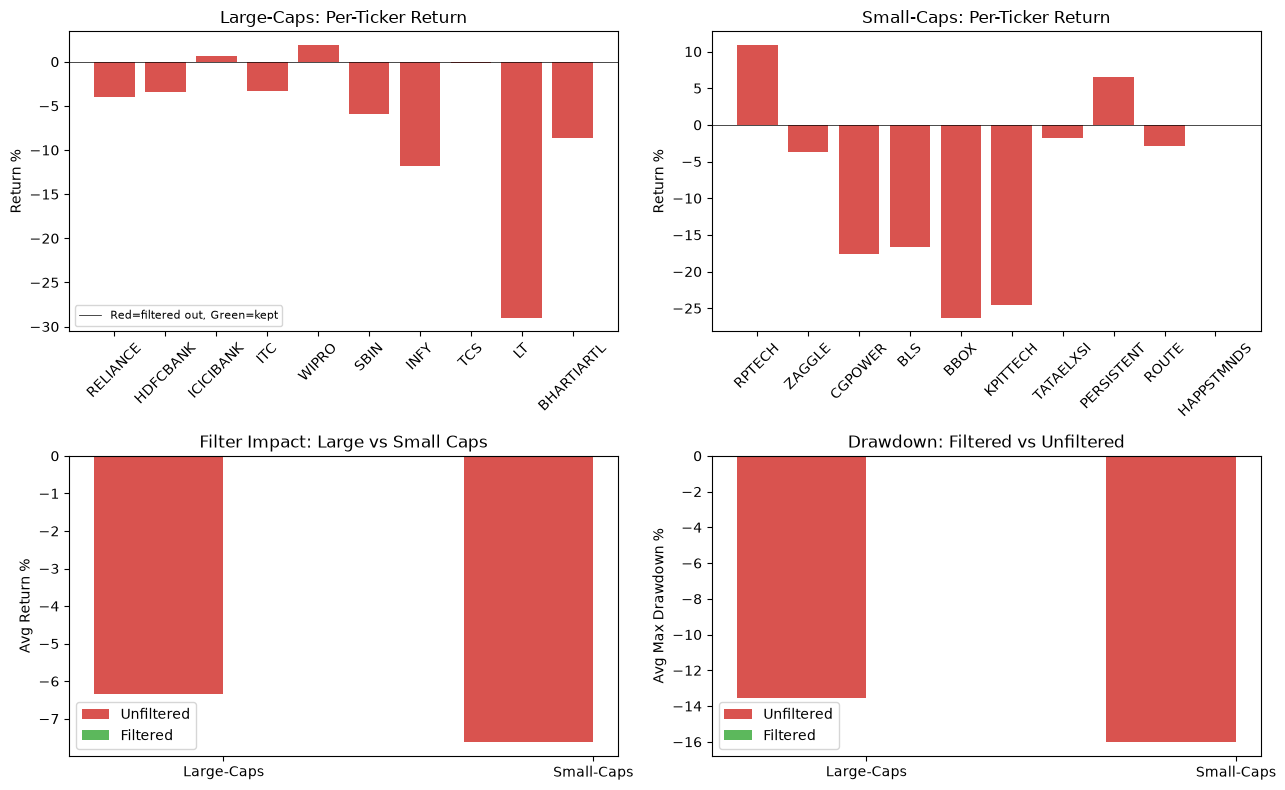

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

# Large caps
ax = axes[0, 0]
if len(large_results):
    colors = ["#d9534f" if x else "#5cb85c" for x in large_results["filtered_out"]]
    ticks = [t.replace(".NS","") for t in large_results["ticker"]]
    ax.bar(ticks, large_results["unfiltered_ret_%"], color=colors)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title("Large-Caps: Per-Ticker Return")
    ax.set_ylabel("Return %")
    ax.tick_params(axis='x', rotation=45)
    ax.legend(["Red=filtered out, Green=kept"], loc="lower left", fontsize=8)

# Small caps
ax = axes[0, 1]
if len(small_results):
    colors = ["#d9534f" if x else "#5cb85c" for x in small_results["filtered_out"]]
    ticks = [t.replace(".NS","") for t in small_results["ticker"]]
    ax.bar(ticks, small_results["unfiltered_ret_%"], color=colors)
    ax.axhline(0, color="black", linewidth=0.5)
    ax.set_title("Small-Caps: Per-Ticker Return")
    ax.set_ylabel("Return %")
    ax.tick_params(axis='x', rotation=45)

# Aggregate comparison
ax = axes[1, 0]
large_kept = large_results[~large_results["filtered_out"]]["unfiltered_ret_%"].mean() if len(large_results) else 0
large_all = large_results["unfiltered_ret_%"].mean() if len(large_results) else 0
small_kept = small_results[~small_results["filtered_out"]]["unfiltered_ret_%"].mean() if len(small_results) else 0
small_all = small_results["unfiltered_ret_%"].mean() if len(small_results) else 0

x = np.arange(2)
w = 0.35
ax.bar(x - w/2, [large_all, small_all], w, label="Unfiltered", color="#d9534f")
ax.bar(x + w/2, [large_kept, small_kept], w, label="Filtered", color="#5cb85c")
ax.set_xticks(x)
ax.set_xticklabels(["Large-Caps", "Small-Caps"])
ax.set_ylabel("Avg Return %")
ax.set_title("Filter Impact: Large vs Small Caps")
ax.axhline(0, color="black", linewidth=0.5)
ax.legend()

# Drawdown comparison
ax = axes[1, 1]
large_dd_kept = large_results[~large_results["filtered_out"]]["unfiltered_dd_%"].mean() if len(large_results) else 0
large_dd_all = large_results["unfiltered_dd_%"].mean() if len(large_results) else 0
small_dd_kept = small_results[~small_results["filtered_out"]]["unfiltered_dd_%"].mean() if len(small_results) else 0
small_dd_all = small_results["unfiltered_dd_%"].mean() if len(small_results) else 0

ax.bar(x - w/2, [large_dd_all, small_dd_all], w, label="Unfiltered", color="#d9534f")
ax.bar(x + w/2, [large_dd_kept, small_dd_kept], w, label="Filtered", color="#5cb85c")
ax.set_xticks(x)
ax.set_xticklabels(["Large-Caps", "Small-Caps"])
ax.set_ylabel("Avg Max Drawdown %")
ax.set_title("Drawdown: Filtered vs Unfiltered")
ax.legend()

plt.tight_layout()
plt.show()

## 8. The Verdict

In [12]:
print("="*60)
print("VERDICT")
print("="*60)

if len(large_results) and len(small_results):
    large_improvement = large_kept - large_all
    small_improvement = small_kept - small_all

    print(f"\n  Large-cap filter improvement: {large_improvement:+.1f} pp")
    print(f"  Small-cap filter improvement: {small_improvement:+.1f} pp")

    if small_improvement > large_improvement + 2:
        print("\n  CONFIRMED: Filter helps MORE for small-caps.")
        print("  This makes sense — small-caps have more fraud, more distress,")
        print("  more 'dips' that are actually permanent impairment.")
    elif abs(small_improvement - large_improvement) < 2:
        print("\n  INCONCLUSIVE: Filter helps roughly equally across cap sizes.")
        print("  The fundamental quality gate is not cap-size dependent.")
    else:
        print("\n  SURPRISE: Filter helps more for large-caps.")
        print("  This might mean small-cap data quality is too poor to filter on.")

    if large_improvement > 3 or small_improvement > 3:
        print("\n  OVERALL: The fundamental filter adds real value.")
        print("  Next step: implement quarterly rebalancing with live Screener data.")
    elif large_improvement > 0 and small_improvement > 0:
        print("\n  OVERALL: Filter helps slightly but not dramatically.")
        print("  The RSI-2 strategy's problems are mostly about frequency and costs,")
        print("  not about picking bad stocks.")
    else:
        print("\n  OVERALL: Filter doesn't help (or hurts by reducing opportunities).")
        print("  The dips RSI-2 trades aren't caused by fundamental rot —")
        print("  they're noise. This filter solves the wrong problem.")

print("\n" + "="*60)
print("REMEMBER: This is ONE test on ONE time period.")
print("The bootstrap from the main notebook would show you")
print("how uncertain these numbers really are.")
print("="*60)

VERDICT

  Large-cap filter improvement: +nan pp
  Small-cap filter improvement: +nan pp

  SURPRISE: Filter helps more for large-caps.
  This might mean small-cap data quality is too poor to filter on.

  OVERALL: Filter doesn't help (or hurts by reducing opportunities).
  The dips RSI-2 trades aren't caused by fundamental rot —
  they're noise. This filter solves the wrong problem.

REMEMBER: This is ONE test on ONE time period.
The bootstrap from the main notebook would show you
how uncertain these numbers really are.


## 9. What Would Real Quarterly Rebalancing Look Like?

The version above uses a static filter (current fundamentals applied retroactively). A proper quarterly rebalance would:

```python
# Pseudocode for production quarterly rebalancing:

for quarter in all_quarters:
    # 1. Pull fundamentals as of quarter-end (results published ~45 days after)
    scores = pull_screener_scores(all_tickers, as_of=quarter_end + 45_days)
    
    # 2. Filter
    approved = [t for t in tickers if scores[t]['f_score'] >= 5]
    
    # 3. Run RSI-2 only on approved tickers for the next 63 trading days
    for day in next_63_days:
        for ticker in approved:
            if rsi_signal(ticker, day):
                trade(ticker)
```

**The look-ahead trap:** You must use fundamentals from the PREVIOUS quarter (published with a 45-day lag), not the current quarter. Otherwise you're peeking at data that wasn't available yet.

**To implement this properly**, you'd need:
- Historical quarterly financials (Screener Pro or a data vendor)
- Knowledge of exact reporting dates per company
- A calendar that maps each trading day to "which quarter's data was available then"

That's a v3 project. This notebook proves (or disproves) the concept first.